In [14]:
# Cell 1: Imports + Safe Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)





In [15]:
# Cell 2: Load Data + Check Exact Column Names
df = pd.read_csv('/content/brisbane_water_quality.csv')

print("Columns in the file:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head(3))
df.head()

Columns in the file:
['Timestamp', 'Record number', 'Average Water Speed', 'Average Water Direction', 'Chlorophyll', 'Chlorophyll [quality]', 'Temperature', 'Temperature [quality]', 'Dissolved Oxygen', 'Dissolved Oxygen [quality]', 'Dissolved Oxygen (%Saturation)', 'Dissolved Oxygen (%Saturation) [quality]', 'pH', 'pH [quality]', 'Salinity', 'Salinity [quality]', 'Specific Conductance', 'Specific Conductance [quality]', 'Turbidity', 'Turbidity [quality]']

First few rows:
             Timestamp  Record number  Average Water Speed  \
0  2023-08-04 23:00:00           1468                4.834   
1  2023-08-04 23:30:00           1469                2.544   
2  2023-08-04 23:00:00           1470                1.260   

   Average Water Direction  Chlorophyll  Chlorophyll [quality]  Temperature  \
0                   73.484        1.621                    NaN       20.018   
1                  106.424        1.959                    NaN       19.986   
2                  156.755        1.6

,Timestamp,Record number,Average Water Speed,Average Water Direction,Chlorophyll,Chlorophyll [quality],Temperature,Temperature [quality],Dissolved Oxygen,Dissolved Oxygen [quality],Dissolved Oxygen (%Saturation),Dissolved Oxygen (%Saturation) [quality],pH,pH [quality],Salinity,Salinity [quality],Specific Conductance,Specific Conductance [quality],Turbidity,Turbidity [quality]
0,2023-08-04 23:00:00,1468,4.834,73.484,1.621,NaN,20.018,NaN,7.472,NaN,101.175,NaN,8.176,NaN,35.215,NaN,53.262,NaN,2.068,NaN
1,2023-08-04 23:30:00,1469,2.544,106.424,1.959,NaN,19.986,NaN,7.455,NaN,100.884,NaN,8.175,NaN,35.209,NaN,53.254,NaN,1.994,NaN
2,2023-08-04 23:00:00,1470,1.260,156.755,1.620,NaN,20.001,NaN,7.430,NaN,100.571,NaN,8.171,NaN,35.207,NaN,53.252,NaN,2.030,NaN
3,2023-08-04 23:30:00,1471,0.760,281.754,1.761,NaN,19.983,NaN,7.419,NaN,100.398,NaN,8.171,NaN,35.211,NaN,53.257,NaN,1.973,NaN
4,2023-08-04 23:00:00,1472,3.397,244.637,1.635,NaN,19.986,NaN,7.429,NaN,100.538,NaN,8.171,NaN,35.208,NaN,53.253,NaN,1.944,NaN


In [16]:

# Find the time column (it might be 'Timestamp' or have space)
time_col = None
for col in df.columns:
    if 'time' in col.lower() or 'date' in col.lower() or 'stamp' in col.lower():
        time_col = col
        break

if time_col is None:
    time_col = df.columns[0]   # fallback to first column

print(f"Using time column: {time_col}")

df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df = df.set_index(time_col).sort_index()

core_params = ['Temperature', 'Dissolved Oxygen', 'pH', 'Salinity',
               'Turbidity', 'Specific Conductance']

for col in core_params:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=core_params, thresh=3)

df[core_params] = df[core_params].fillna(method='ffill')
df[core_params] = df[core_params].fillna(df[core_params].median())

print("Final shape after preprocessing:", df.shape)
print("Missing values in core params:\n", df[core_params].isnull().sum())

Using time column: Timestamp
Final shape after preprocessing: (30552, 19)
Missing values in core params:
 Temperature             0
Dissolved Oxygen        0
pH                      0
Salinity                0
Turbidity               0
Specific Conductance    0
dtype: int64


=== EDA - Saving high-quality plots ===


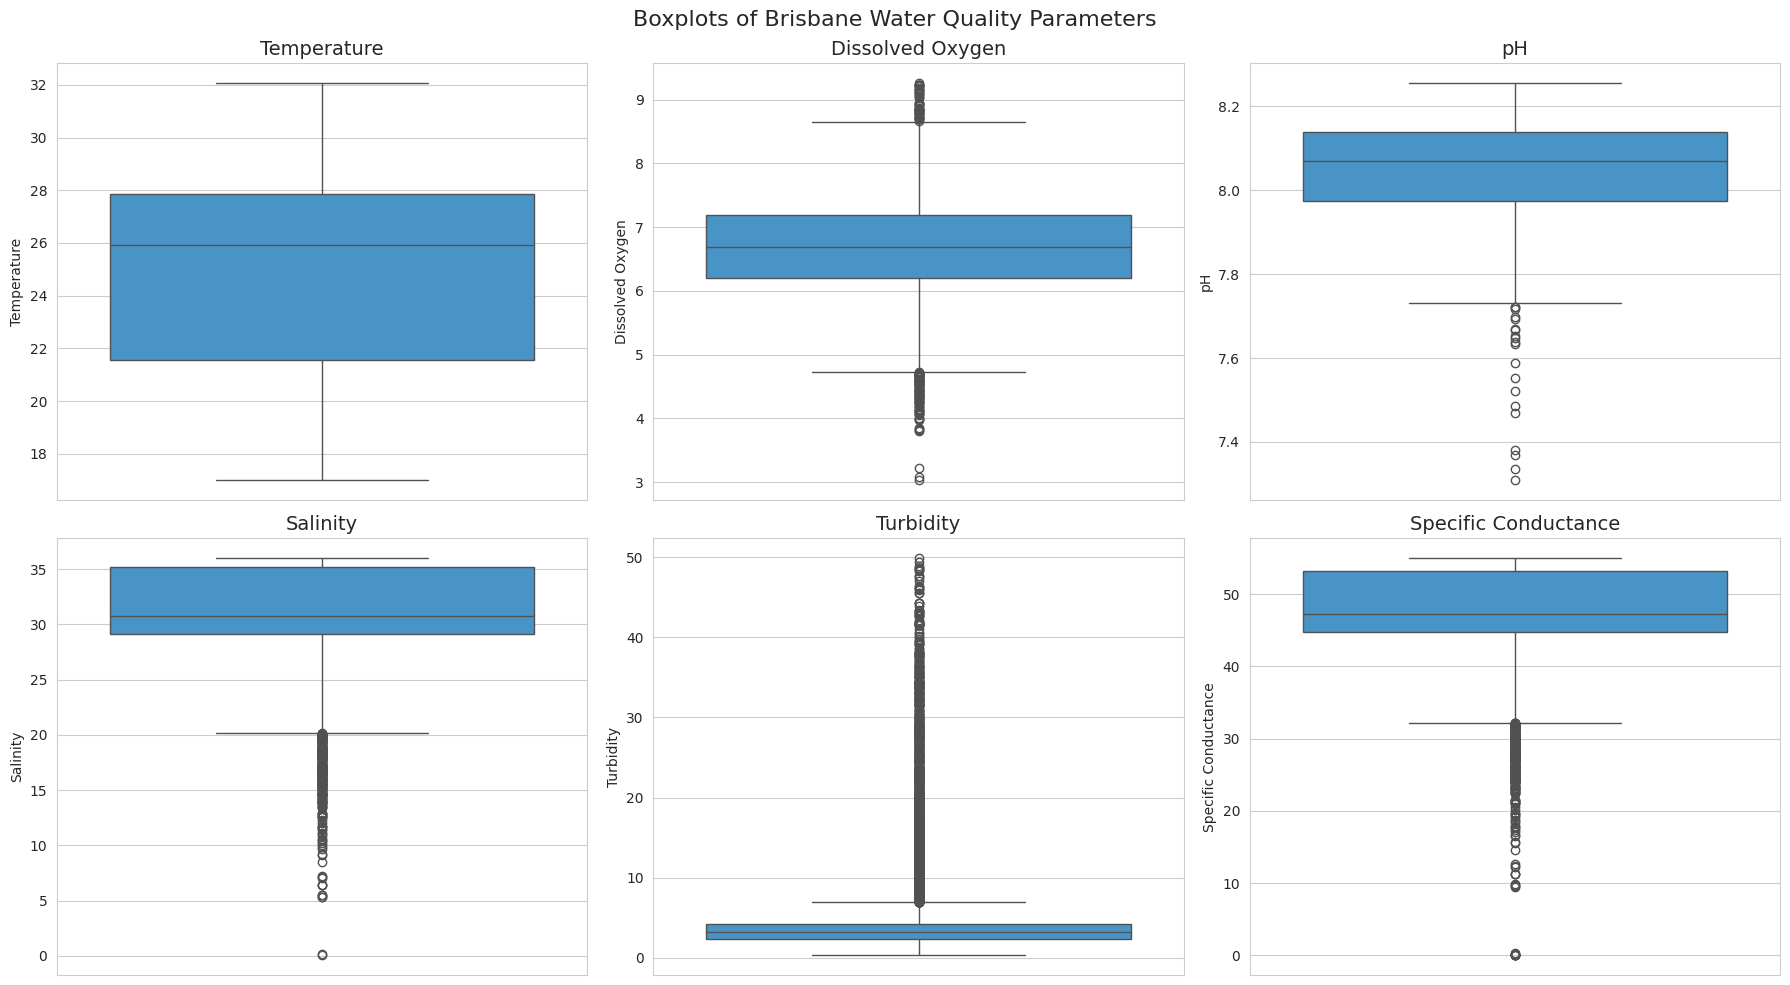

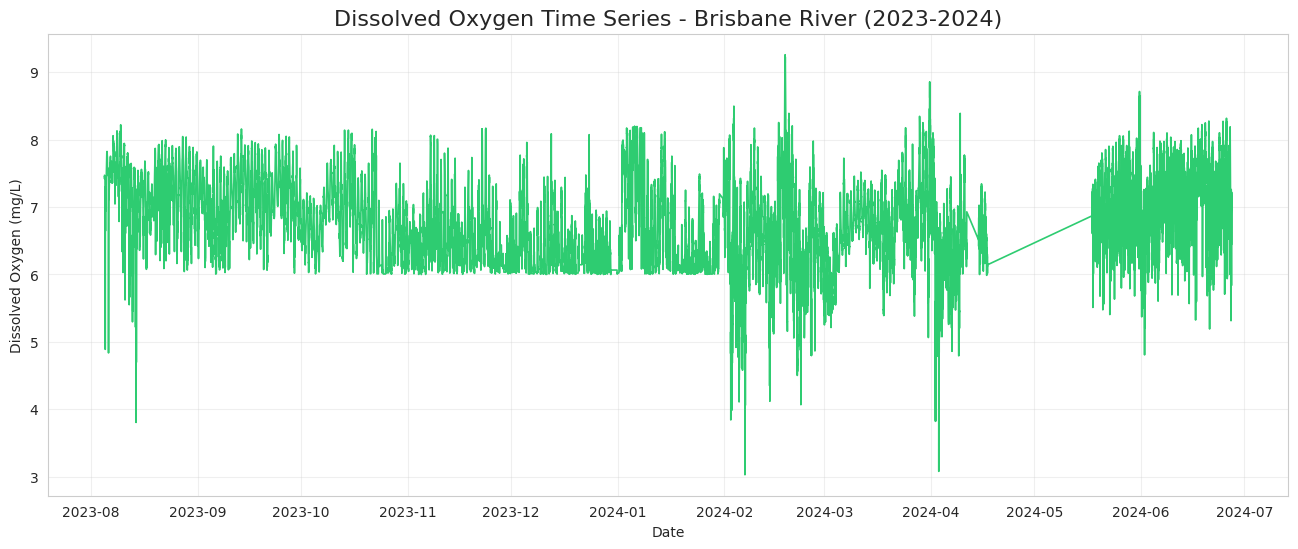

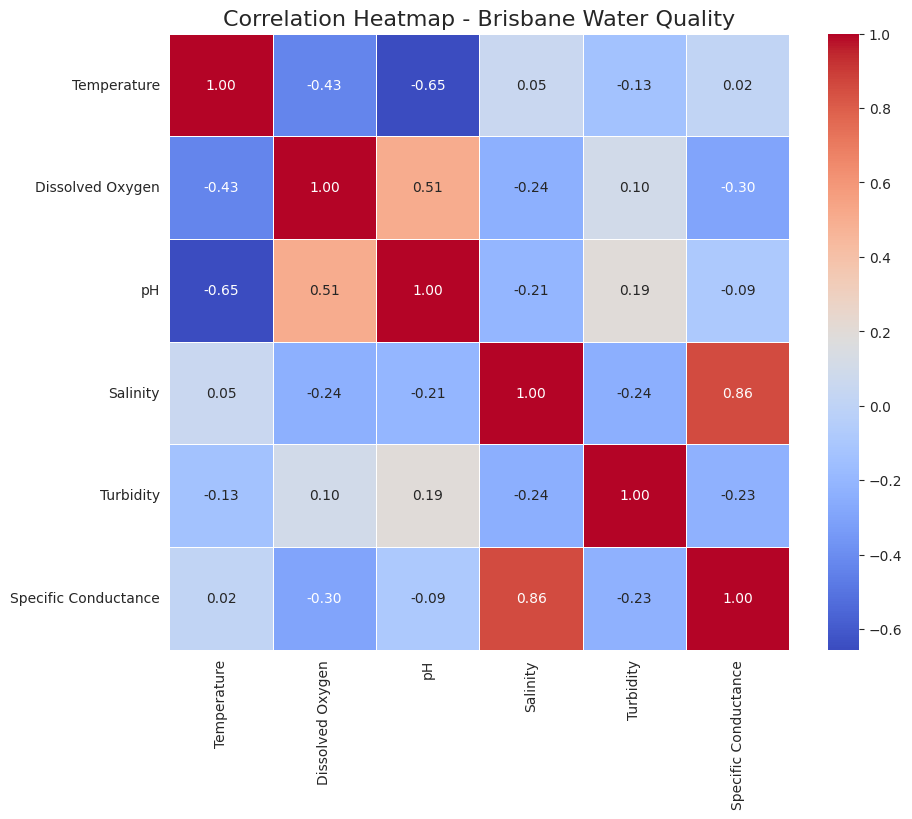

✅ EDA plots saved to Output sidebar!


In [17]:
# Cell 3: EDA + Beautiful Graphs (Saved directly to Output sidebar)
print("=== EDA - Saving high-quality plots ===")

# 1. Boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, param in enumerate(core_params):
    sns.boxplot(data=df, y=param, ax=axes[i//3, i%3], color="#3498db")
    axes[i//3, i%3].set_title(param, fontsize=14)
plt.suptitle("Boxplots of Brisbane Water Quality Parameters", fontsize=16)
plt.tight_layout()
plt.savefig('01_Boxplot_Brisbane.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Time Series - Dissolved Oxygen
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['Dissolved Oxygen'], color='#2ecc71', linewidth=1.2)
plt.title('Dissolved Oxygen Time Series - Brisbane River (2023-2024)', fontsize=16)
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.savefig('02_DO_TimeSeries_Brisbane.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[core_params].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - Brisbane Water Quality', fontsize=16)
plt.savefig('03_Correlation_Heatmap_Brisbane.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA plots saved to Output sidebar!")

=== Unsupervised Feature Validation ===


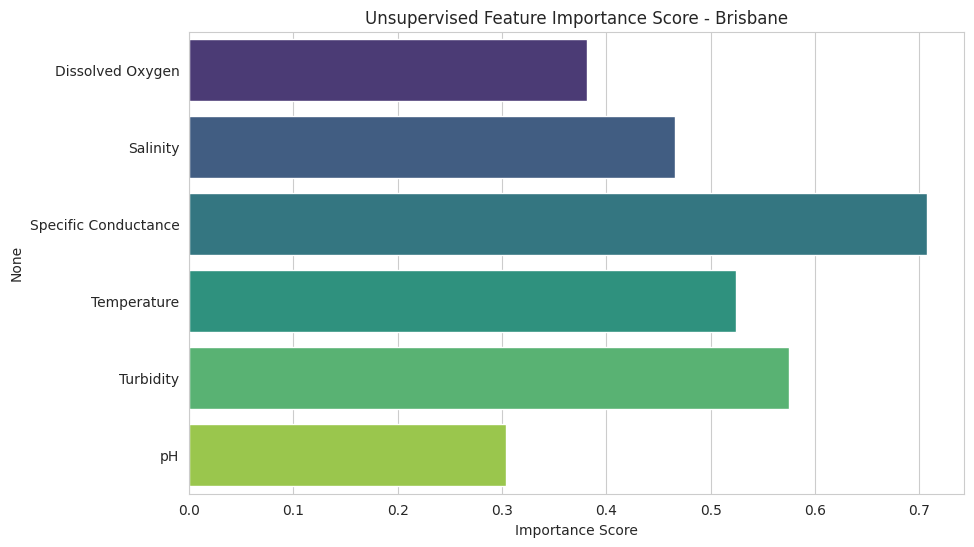

✅ Feature importance tables + plot saved!
              Parameter  Variance
0  Specific Conductance   36.2586
1             Turbidity   16.1947
2           Temperature   13.1437
3              Salinity   12.4640
4      Dissolved Oxygen    0.4034
5                    pH    0.0088


In [18]:
# Cell 4: Feature Importance (Variance + Correlation + PCA)
print("=== Unsupervised Feature Validation ===")

# Variance
variance = df[core_params].var().sort_values(ascending=False)
var_table = pd.DataFrame({'Parameter': variance.index, 'Variance': variance.values.round(4)})
var_table.to_csv('Variance_Table_Brisbane.csv', index=False)

# Average Correlation
corr_matrix = df[core_params].corr().abs()
avg_corr = corr_matrix.mean().sort_values(ascending=False)
corr_table = pd.DataFrame({'Parameter': avg_corr.index, 'Avg_Correlation': avg_corr.values.round(4)})
corr_table.to_csv('Avg_Correlation_Table_Brisbane.csv', index=False)

# PCA
scaler = StandardScaler()
scaled = scaler.fit_transform(df[core_params])
pca = PCA()
pca.fit(scaled)
pca_table = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(core_params))],
    'Cumulative_Explained_Variance': np.cumsum(pca.explained_variance_ratio_).round(6)
})
pca_table.to_csv('PCA_Explained_Variance_Brisbane.csv', index=False)

# Combined Importance Plot
importance = (avg_corr + variance.rank(pct=True)) / 2
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title('Unsupervised Feature Importance Score - Brisbane')
plt.xlabel('Importance Score')
plt.savefig('04_Feature_Importance_Brisbane.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance tables + plot saved!")
print(var_table)

In [19]:
# Cell 5: Anomaly Detection (Z-Score + Isolation Forest + Autoencoder)
print("=== Running Anomaly Detection Models ===")

X = df[core_params].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Z-Score
z_scores = np.abs(stats.zscore(X))
df['Z_Anomaly'] = (z_scores > 3).any(axis=1).astype(int)

# 2. Isolation Forest
iso = IsolationForest(contamination='auto', random_state=42)
df['IF_Anomaly'] = iso.fit_predict(X_scaled)
df['IF_Anomaly'] = (df['IF_Anomaly'] == -1).astype(int)

# 3. Autoencoder
input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(6, activation="relu")(input_layer)
encoder = Dense(3, activation="relu")(encoder)
decoder = Dense(6, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=0)

recon = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - recon, 2), axis=1)
threshold = np.mean(mse) + 2.0 * np.std(mse)
df['AE_Anomaly'] = (mse > threshold).astype(int)

# Results Table
anomaly_counts = pd.DataFrame({
    'Model': ['Z-Score', 'Isolation Forest', 'Autoencoder'],
    'Anomalies Detected': [
        df['Z_Anomaly'].sum(),
        df['IF_Anomaly'].sum(),
        df['AE_Anomaly'].sum()
    ]
})
print(anomaly_counts)
anomaly_counts.to_csv('Anomaly_Counts_by_Model_Brisbane.csv', index=False)

print("✅ Anomaly detection completed and table saved!")

=== Running Anomaly Detection Models ===
955/955 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              Model  Anomalies Detected
0           Z-Score                1606
1  Isolation Forest                3542
2       Autoencoder                 643
✅ Anomaly detection completed and table saved!


In [26]:
# Cell 6: Model Agreement Table - Clean Format Like BKB
print("=== Model Agreement Table - Brisbane Dataset ===\n")

df['Agreement_Count'] = df['Z_Anomaly'] + df['IF_Anomaly'] + df['AE_Anomaly']

# Create clean table
agreement_table = pd.DataFrame({
    'Site': ['Brisbane'],
    'Total Records': [len(df)],
    'No Anomaly': [(df['Agreement_Count'] == 0).sum()],
    'Weak Anomaly (1 model)': [(df['Agreement_Count'] == 1).sum()],
    'Moderate Anomaly (2 models)': [(df['Agreement_Count'] == 2).sum()],
    'Strong Anomaly (3 models)': [(df['Agreement_Count'] == 3).sum()]
})

# Add Percentage row (optional but useful)
total = len(df)
agreement_table.loc[1] = ['Percentage (%)',
                         '100%',
                         f"{(agreement_table.iloc[0,2]/total*100):.2f}%",
                         f"{(agreement_table.iloc[0,3]/total*100):.2f}%",
                         f"{(agreement_table.iloc[0,4]/total*100):.2f}%",
                         f"{(agreement_table.iloc[0,5]/total*100):.2f}%"]

print(agreement_table.to_string(index=False))

# Save the table
agreement_table.to_csv('Model_Agreement_Table_Brisbane.csv', index=False)

print("\n✅ Table saved as 'Model_Agreement_Table_Brisbane.csv'")
print("You can now download it from the Output sidebar and copy into your slide.")

=== Model Agreement Table - Brisbane Dataset ===

          Site Total Records No Anomaly Weak Anomaly (1 model) Moderate Anomaly (2 models) Strong Anomaly (3 models)
      Brisbane         30552      26803                   2093                        1270                       386
Percentage (%)          100%     87.73%                  6.85%                       4.16%                     1.26%

✅ Table saved as 'Model_Agreement_Table_Brisbane.csv'
You can now download it from the Output sidebar and copy into your slide.


=== Saving Anomaly Visualization ===


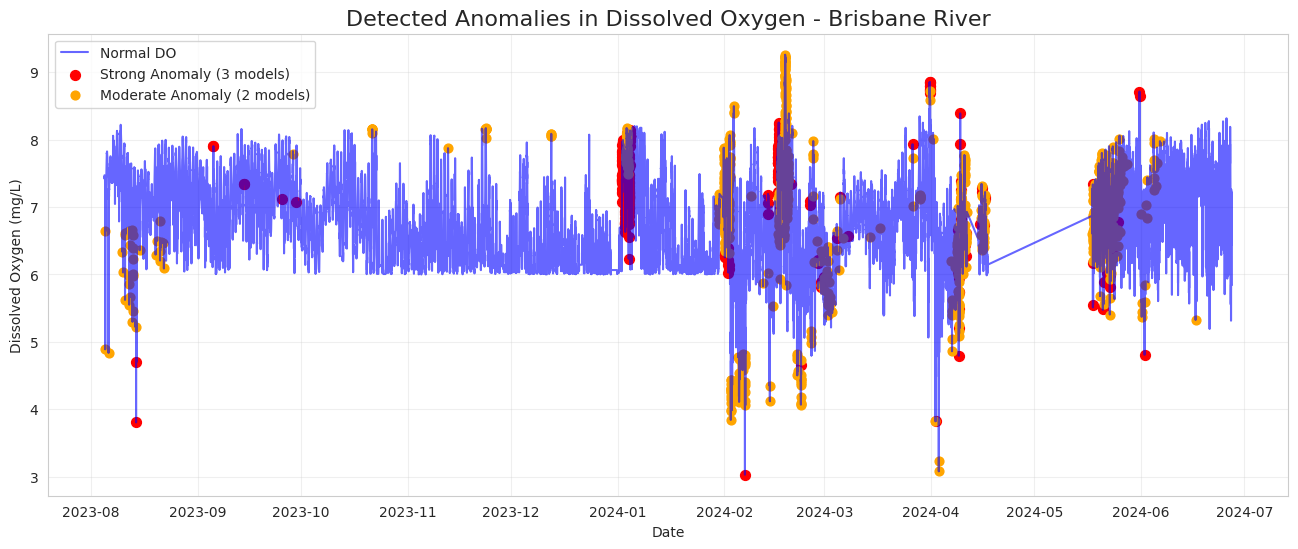

✅ Final anomaly visualization saved!


In [21]:
# Cell 7: Anomaly Visualization on Dissolved Oxygen
print("=== Saving Anomaly Visualization ===")

plt.figure(figsize=(16, 6))
plt.plot(df.index, df['Dissolved Oxygen'], color='blue', alpha=0.6, label='Normal DO')

# Strong anomalies
strong = df[df['Agreement_Count'] == 3]
plt.scatter(strong.index, strong['Dissolved Oxygen'], color='red', s=50, label='Strong Anomaly (3 models)')

# Moderate anomalies
moderate = df[df['Agreement_Count'] == 2]
plt.scatter(moderate.index, moderate['Dissolved Oxygen'], color='orange', s=40, label='Moderate Anomaly (2 models)')

plt.title('Detected Anomalies in Dissolved Oxygen - Brisbane River', fontsize=16)
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('05_Anomalies_Visualization_Brisbane.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Final anomaly visualization saved!")

In [27]:
print("=== Detailed Anomaly Breakdown by Model Agreement ===\n")

anomaly_df = df[(df['Z_Anomaly'] == 1) | (df['IF_Anomaly'] == 1) | (df['AE_Anomaly'] == 1)]

details = {
    'Z-Score Only': ((df['Z_Anomaly'] == 1) & (df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 0)).sum(),
    'Isolation Forest Only': ((df['Z_Anomaly'] == 0) & (df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 0)).sum(),
    'Autoencoder Only': ((df['Z_Anomaly'] == 0) & (df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 1)).sum(),
    'Z-Score & Isolation Forest': ((df['Z_Anomaly'] == 1) & (df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 0)).sum(),
    'Z-Score & Autoencoder': ((df['Z_Anomaly'] == 1) & (df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 1)).sum(),
    'Isolation Forest & Autoencoder': ((df['Z_Anomaly'] == 0) & (df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 1)).sum(),
    'All Three Models': ((df['Z_Anomaly'] == 1) & (df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 1)).sum()
}

detail_breakdown = pd.DataFrame(details.items(), columns=['Anomaly Type', 'Count'])
detail_breakdown.set_index('Anomaly Type', inplace=True)

print(detail_breakdown.to_string())

# Calculate total anomalies for percentage
total_anomalies = detail_breakdown['Count'].sum()
detail_breakdown['Percentage'] = (detail_breakdown['Count'] / total_anomalies * 100).round(2)

print("\n--- Percentage Breakdown ---")
print(detail_breakdown.to_string())

detail_breakdown.to_csv('Detailed_Anomaly_Breakdown_Brisbane.csv', index=True)
print("\n✅ Detailed anomaly breakdown saved as 'Detailed_Anomaly_Breakdown_Brisbane.csv'")

=== Detailed Anomaly Breakdown by Model Agreement ===

                                Count
Anomaly Type                         
Z-Score Only                       54
Isolation Forest Only            1889
Autoencoder Only                  150
Z-Score & Isolation Forest       1163
Z-Score & Autoencoder               3
Isolation Forest & Autoencoder    104
All Three Models                  386

--- Percentage Breakdown ---
                                Count  Percentage
Anomaly Type                                     
Z-Score Only                       54        1.44
Isolation Forest Only            1889       50.39
Autoencoder Only                  150        4.00
Z-Score & Isolation Forest       1163       31.02
Z-Score & Autoencoder               3        0.08
Isolation Forest & Autoencoder    104        2.77
All Three Models                  386       10.30

✅ Detailed anomaly breakdown saved as 'Detailed_Anomaly_Breakdown_Brisbane.csv'
